# Results analysis notebook

This notebook was developed as part of the Master’s thesis of June Rossen and is one of two notebooks used to analyse the results of the wind power placement multi-objective optimization.

It is designed to process and visualise the results across the three scenarios of the study. Provided one has all the necessary files, the notebook can be run as is.

## Workflow

The notebook follows the steps below:

1. List the scenario names that will be analysed.
2. Define the names of all relevant input files based on the scenarios and the corresponding runs (when multiple runs exist).
3. Load all required data into lists of variables.
4. Compile the multi-objective optimization (MOO) solutions into a single dataframe.
5. Extract and prepare the TOTAL solutions for all scenarios.  
   See the *Results* section of the thesis for a detailed description of these solutions.
6. Generate the plots used for the analysis and discussion.
7. Provide additional plotting routines (not used in the thesis) in the final section for exploratory analysis.


In [48]:
#imports
import numpy as np
import geopandas as gpd
import pandas as pd
import dill

from pymoo.indicators.hv import HV
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib import rcParams

from matplotlib_venn import venn2
from matplotlib_venn import venn3

import seaborn as sns

from scipy.stats import pearsonr

from pymoo.visualization.scatter import Scatter
from pymoo.visualization.pcp import PCP
from pymoo.visualization.heatmap import Heatmap
from pymoo.visualization.petal import Petal
from pymoo.visualization.radar import Radar
from pymoo.visualization.radviz import Radviz
from pymoo.visualization.star_coordinate import StarCoordinate

plt.rcParams['font.family'] = 'serif'

## Preparing scenario and file names
The logic is similar to the 3_1_ResultsAnalysis_per_scenario.ipynb notebook, with added loops and lists to get the information for all scenarios/regions.

In retrospect, the MCDA solutions are not necessary for the analysis that was used in the thesis, but the code is kept due to additional code at the end of this notebook that makes use of it.

In [ ]:
scenarios = ["100TWh", "30TWh", "NO1", "NO2", "NO3", "NO4", "NO5"]
scenario_names = ["100_NAT", "30_NAT", "100_REG"]

best_runs = ["Run1", "Run1", "Run1", "Run3", "Run1", "Run1", "Run2"]

# This defines the minimum production requirement based on the chosen scenario
region_shares = [1, 0.3, 0.257, 0.262, 0.210, 0.146, 0.124]

# Total land surface of the respective scenarios
total_land_areas = [354037, 354037, 59889, 52426, 76948, 134522, 30252]

# Useful color palettes
colors = sns.crayon_palette(["Red", "Orange", "Sunglow", "Screamin' Green", "Green", "Denim", "Vivid Violet"])
colors_3scenarios = sns.crayon_palette(["Red", "Orange", "Tropical Rain Forest"])
colors_objectives = ['#2ca02c', '#1f77b4','#e377c2','#9467bd','#ff7f0e','#d62728','#8c564b']

min_productions = []
input_data_filenames = []
F_mcda_filenames = []
X_mcda_filenames = []
results_filenames = []

for s in range(len(scenarios)):
    scenario = scenarios[s]

    min_productions.append(100_000 * region_shares[s])
    input_data_filenames.append("Input_optimization/" + scenario + "_normalized_merged.gpkg")
    F_mcda_filenames.append("Input_optimization/" + scenario + "_F_mcda.npy")
    X_mcda_filenames.append("Input_optimization/" + scenario + "_X_mcda.csv")
    results_filenames.append("Output_optimization/" + scenario + "_" + best_runs[s] + "_result.dill")

## Loading optimization results and important geodataframe data
The logic is similar to the 3_1_ResultsAnalysis_per_scenario.ipynb notebook, with added loops and lists to get the information for all scenarios/regions

In [ ]:
my_input_datas = []
ress = []
F_mcdas = []
X_mcdas = []
F_mcda_7_objectivess = []
X_mcda_7_objectivess = []
F_mcda_per_TWh_7_objectivess = []

# Add extra information to analyse available area, used area, number of turbines used, number of 3 MW and 5 MW turbines used
extra_info = gpd.read_file("data/SSB_techlegalfiltered_opticriteria.gpkg")
my_input_data_extra_infos = []

# When the MCDA solutions were initially generated, the order of the indicators was different than currently, and there were additional indicators. This cell fixes this for the results analysis notebook.
# initial order = ["AEP_GWh_efficient", "Daily_exposure", "Culture", "Landscape_change", "Sensitive_fauna", "Technical_difficulty", "Costs", "Social_indicator", "Environmental_indicator", "Technical_indicator", "Global_indicator"]
rows_7 = [3, 4, 1, 2, 6, 5, 10]

for s in range(len(scenarios)):

    my_input_datas.append(gpd.read_file(input_data_filenames[s]))

    with open(results_filenames[s], 'rb') as f:
        ress.append(dill.load(f))

    F_mcdas.append(np.load(F_mcda_filenames[s]))
    X_mcdas.append(np.loadtxt(X_mcda_filenames[s], dtype=int, delimiter=","))
    F_mcda_7_objectivess.append(F_mcdas[s][rows_7])
    X_mcda_7_objectivess.append(X_mcdas[s][rows_7])

    my_input_data_extra_infos.append(my_input_datas[s].merge(
        extra_info[["SSBid", "pct_NoGo", "potential_nb_3MW_turbines", "potential_nb_5MW_turbines", "Best_turbine_model", "nb_turbines"]],
        left_on="SSBid",
        right_on="SSBid",
        how="left"))

    my_input_data_extra_infos[s]["Available_surface"] = 1 - my_input_data_extra_infos[s]["pct_NoGo"]

    my_input_data_extra_infos[s]["nb_3MW_turbines"] = np.where(
        my_input_data_extra_infos[s]["Best_turbine_model"] == "avg_AEP_3MW",
        my_input_data_extra_infos[s]["potential_nb_3MW_turbines"], 0
    )

    my_input_data_extra_infos[s]["nb_5MW_turbines"] = np.where(
        my_input_data_extra_infos[s]["Best_turbine_model"] == "avg_AEP_5MW",
        my_input_data_extra_infos[s]["potential_nb_5MW_turbines"], 0
    )

    my_input_data_extra_infos[s].drop(columns=["potential_nb_3MW_turbines", "potential_nb_5MW_turbines"], inplace=True)

## Prepare the MOO solutions
The logic is similar to the 3_1_ResultsAnalysis_per_scenario.ipynb notebook, with added loops and lists to get the information for all scenarios/regions

In [ ]:
# All lists of names
objective_names = [
    "Landscape change", "Sensitive fauna",
    "Daily exposure", "Culture",
    "Costs", "Technical difficulty"
]

objective_names_plot_labels = [
    "Landscape\nchange", "Sensitive\nfauna",
    "Daily\nexposure", "Culture",
    "Costs", "Technical\ndifficulty"
]

objective_names_per_TWh = [
    "Landscape change per TWh", "Sensitive fauna per TWh",
    "Daily exposure per TWh", "Culture per TWh",
    "Costs per TWh", "Technical difficulty per TWh"
]

objective_names_7 = [
    "Landscape change", "Sensitive fauna",
    "Daily exposure", "Culture",
    "Costs", "Technical difficulty",
    "Total impact"
]

metrics_of_interest_plot_labels = ["Total\nimpact", "Total area\n[$\\mathregular{km^2}$]", "Number\nturbines", "Number 3MW\nturbines", "Number 5MW\nturbines"]
metrics_of_interest_absolute = ["Total impact", "Total area km2", "Number turbines", "Number 3MW turbines", "Number 5MW turbines"]
metrics_of_interest_per_TWh = ["Total impact per TWh", "Total area km2 per TWh", "Number turbines per TWh", "Number 3MW turbines per TWh", "Number 5MW turbines per TWh"]

metrics_absolute = objective_names + metrics_of_interest_absolute
metrics_per_TWh = objective_names_per_TWh + metrics_of_interest_per_TWh

overarching_objective_names = ["Environmental objectives", "Social objectives", "Techno-economic objectives"]

In [ ]:
### Create the dataframes of solutions, based on the objective values of the solutions

number_objectives = 6

Xs = []
Fs = []
Gs = []

F_per_TWhs = []

solution_dfs = []
solution_df_sorteds = []

for s in range(len(scenarios)):
    Xs.append(ress[s].X)
    Fs.append(ress[s].F)
    Gs.append(ress[s].G)

    production_mcda_7_objectives = X_mcda_7_objectivess[s] @ my_input_datas[s]['AEP_GWh'].values
    F_mcda_per_TWh_7_objectivess.append(1000 * F_mcda_7_objectivess[s] / production_mcda_7_objectives[:,None])


    solution_dfs.append(pd.DataFrame(Fs[s], columns=objective_names))

    # Add metrics of interest, such as energy production, number of cells kept, total impact, total area necessary, as well as number of turbines necessary (total, 3 MW and 5 MW)
    production = Xs[s] @ my_input_datas[s]['AEP_GWh'].values
    solution_dfs[s]["Production"] = production

    kept_cells = Xs[s].sum(axis=1)
    solution_dfs[s]["Cells_kept"] = kept_cells

    solution_dfs[s]["Total impact"] = Fs[s].sum(axis=1)

    solution_dfs[s]["Total area km2"] = Xs[s] @ my_input_data_extra_infos[s]["Available_surface"].values

    solution_dfs[s]["Number turbines"] = Xs[s] @ my_input_data_extra_infos[s]["nb_turbines"].values
    solution_dfs[s]["Number 3MW turbines"] = Xs[s] @ my_input_data_extra_infos[s]["nb_3MW_turbines"].values
    solution_dfs[s]["Number 5MW turbines"] = Xs[s] @ my_input_data_extra_infos[s]["nb_5MW_turbines"].values

    F_per_TWhs.append(1000 * Fs[s] / production[:,None])
    # Normalize all of those metrics, as well as the objective values, by the corresponding energy production
    solution_dfs[s][metrics_per_TWh] = 1000 * solution_dfs[s][metrics_absolute].div(solution_dfs[s]["Production"], axis=0)

    number_solutions = solution_dfs[s].shape[0]
    print("Number of final solutions in scenario", scenarios[s], " : ", number_solutions)

    solution_df_sorteds.append(solution_dfs[s].sort_values("Total impact per TWh", ascending=True).copy())

    display(solution_df_sorteds[s])


Number of final solutions in scenario 100TWh  :  400


,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,...,Sensitive fauna per TWh,Daily exposure per TWh,Culture per TWh,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh
189,586.635192,92.284707,207.757769,525.0,113.049411,622.616890,100003.704030,1163,2147.343969,1160.306250,...,0.922813,2.077501,5.249806,1.130452,6.225938,21.472644,11.602633,35.118699,0.919966,34.198733
374,597.093460,100.781845,221.756560,521.5,119.216441,627.126449,100000.957061,1177,2187.474756,1168.772500,...,1.007809,2.217544,5.214950,1.192153,6.271204,21.874538,11.687613,35.409661,1.269988,34.139673
100,602.794033,104.271157,229.110435,519.5,121.517349,630.637093,100352.883899,1187,2207.830065,1175.470000,...,1.039045,2.283048,5.176732,1.210900,6.284195,22.000664,11.713365,35.504710,1.365182,34.139527
142,584.355862,88.482205,223.287633,616.5,118.599887,620.484087,100005.853581,1167,2251.709673,1160.164375,...,0.884770,2.232746,6.164639,1.185929,6.204478,22.515779,11.600965,35.137943,1.079937,34.058006
207,600.220194,100.126159,194.823266,596.5,130.541110,642.688355,100033.209454,1186,2264.899084,1174.720625,...,1.000929,1.947586,5.963020,1.304978,6.424750,22.641472,11.743306,35.508208,1.099635,34.408573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,850.048277,34.007570,515.204333,1339.5,280.284590,929.037624,101004.231643,1703,3948.082394,1398.586875,...,0.336695,5.100819,13.261821,2.774979,9.198007,39.088287,13.846815,44.275373,15.306289,28.969083
164,851.869165,33.116754,517.600094,1321.5,286.005089,932.558813,100364.445728,1707,3942.649914,1400.990000,...,0.329965,5.157206,13.167013,2.849665,9.291725,39.283333,13.959027,44.766849,15.951864,28.814985
58,849.099668,34.758271,515.037817,1328.5,277.291185,928.175516,100047.410895,1700,3932.862457,1396.457500,...,0.347418,5.147937,13.278704,2.771598,9.277357,39.309987,13.957957,44.798761,16.242299,28.556461
9,856.814771,32.537307,516.705620,1326.0,286.254796,935.358486,100394.625446,1710,3953.670980,1400.621875,...,0.324094,5.146746,13.207878,2.851296,9.316818,39.381301,13.951164,44.753392,16.006833,28.746559


Number of final solutions in scenario 30TWh  :  400


,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,...,Sensitive fauna per TWh,Daily exposure per TWh,Culture per TWh,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh
49,168.417807,22.590284,43.169513,149.5,26.933155,180.063653,30010.186048,335,590.674412,334.301250,...,0.752754,1.438495,4.981642,0.897467,6.000085,19.682464,11.139593,33.488629,0.133288,33.355341
87,168.185268,22.304800,47.910395,154.5,27.109375,179.585836,30008.790138,335,599.595675,334.171875,...,0.743276,1.596545,5.148491,0.903381,5.984441,19.980668,11.135800,33.456864,0.133294,33.323569
61,170.204284,23.232639,46.221007,156.0,29.104506,179.194625,30022.234295,338,603.957061,336.950000,...,0.773848,1.539559,5.196149,0.969432,5.968730,20.116992,11.223349,33.808277,0.532938,33.275338
257,171.376328,23.832535,45.335781,158.0,30.069687,179.973709,30036.830493,339,608.588041,337.162500,...,0.793444,1.509340,5.260209,1.001094,5.991768,20.261393,11.224969,33.791848,0.399510,33.392338
374,171.557729,23.881332,45.656886,158.5,30.194441,179.849653,30006.397203,339,609.640041,337.162500,...,0.795875,1.521572,5.282207,1.006267,5.993710,20.317002,11.236354,33.826120,0.399915,33.426206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,254.365794,6.148196,148.555884,414.0,78.191900,284.318688,30010.314916,510,1185.580463,417.684375,...,0.204869,4.950161,13.795257,2.605501,9.474032,39.505765,13.918027,44.951211,17.360698,27.590514
251,254.549623,6.357348,149.125249,413.0,78.542882,284.186906,30000.229474,510,1185.762008,417.927500,...,0.211910,4.970804,13.766561,2.618076,9.472824,39.525098,13.930810,44.999656,17.366534,27.633122
266,256.596317,5.858970,151.915895,413.0,79.170572,285.934716,30161.880627,514,1192.476469,420.893750,...,0.194251,5.036685,13.692780,2.624855,9.480003,39.535879,13.954493,45.056872,17.538694,27.518178
6,254.781789,5.070283,151.006137,416.5,78.219660,285.599467,30005.942868,512,1191.177336,418.520625,...,0.168976,5.032541,13.880584,2.606806,9.518097,39.698047,13.947924,45.057741,17.763148,27.294593


Number of final solutions in scenario NO1  :  400


...

,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,...,Sensitive fauna per TWh,Daily exposure per TWh,Culture per TWh,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh
221,139.665778,19.317914,85.967388,193.5,23.278675,134.111581,21027.610416,274,595.841336,263.200625,...,0.918693,4.088310,9.202187,1.107053,6.377880,28.336141,12.516906,39.091460,6.848139,32.243321
396,127.459558,15.931456,71.835493,234.5,20.837669,129.086073,21012.949904,254,599.650250,253.018125,...,0.758173,3.418630,11.159785,0.991658,6.143168,28.537176,12.041057,36.358531,0.761435,35.597096
364,135.323812,17.262705,72.588908,227.5,22.822724,132.573036,21254.539843,264,608.071185,260.538750,...,0.812189,3.415219,10.703596,1.073781,6.237399,28.609003,12.258028,37.733115,3.575707,34.157409
336,133.840250,16.676680,71.643611,225.5,23.037091,131.326509,21038.282093,262,602.024141,257.371250,...,0.792683,3.405393,10.718556,1.095008,6.242264,28.615651,12.233473,37.740724,3.802592,33.938132
340,135.411698,17.249370,72.445788,227.5,22.951044,132.524297,21218.645399,264,608.082198,260.438750,...,0.812935,3.414251,10.721702,1.081645,6.245653,28.657918,12.274052,37.749818,3.581756,34.168062
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
388,248.794193,35.366421,190.875645,114.0,98.397026,203.373865,21045.524302,429,890.807150,346.034375,...,1.680472,9.069655,5.416829,4.675437,9.663521,42.327629,16.442184,50.889680,14.064748,36.824932
384,249.629245,34.772587,191.724221,110.5,102.588414,204.500342,21054.690239,431,893.714809,348.170625,...,1.651536,9.106010,5.248237,4.872473,9.712816,42.447303,16.536488,51.437470,14.676065,36.761405
192,249.136005,35.509462,190.855089,115.0,98.728292,203.258988,21022.449246,429,892.487836,346.075625,...,1.689121,9.078632,5.470343,4.696327,9.668663,42.454037,16.462193,50.945539,14.080186,36.865352
129,249.741304,34.687130,192.010982,108.5,102.633591,204.616136,21003.057105,431,892.189143,347.588750,...,1.651528,9.142049,5.165915,4.886602,9.742207,42.479013,16.549436,51.563922,14.902592,36.661330


Number of final solutions in scenario NO4  :  400


,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,...,Sensitive fauna per TWh,Daily exposure per TWh,Culture per TWh,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh
276,78.507140,10.018449,14.541206,78.5,11.261584,86.715510,14615.116404,157,279.543889,156.796875,...,0.685485,0.994943,5.371151,0.770544,5.933275,19.127038,10.728404,32.226907,0.000000,32.226907
219,78.586299,9.968693,15.037553,79.0,11.314868,86.332396,14601.140226,157,280.239809,156.786875,...,0.682734,1.029889,5.410536,0.774930,5.912716,19.193009,10.737988,32.257755,0.000000,32.257755
41,79.025385,9.903895,15.062418,80.5,11.199664,87.210322,14606.919080,158,282.901684,157.635000,...,0.678028,1.031184,5.511087,0.766737,5.970480,19.367649,10.791803,32.655757,0.821528,31.834229
46,80.132066,9.279566,15.150148,83.0,13.001796,90.203577,14609.378359,160,290.767153,159.498750,...,0.635179,1.037015,5.681282,0.889962,6.174361,19.902774,10.917559,32.924057,0.547593,32.376463
145,80.267712,9.740755,15.715095,82.0,12.940994,90.050049,14602.880531,160,290.714605,159.449375,...,0.667043,1.076164,5.615330,0.886195,6.166595,19.908031,10.919036,32.801748,0.273919,32.527829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10,200.613224,76.472217,163.875021,1.0,75.158147,149.470361,14667.299442,339,666.588968,238.711250,...,5.213790,11.172815,0.068179,5.124198,10.190721,45.447287,16.275065,52.634093,20.044590,32.589503
104,199.938082,76.082707,163.574001,1.5,74.845720,149.123928,14632.049230,338,665.064437,237.692500,...,5.199730,11.179159,0.102515,5.115191,10.191596,45.452583,16.244649,52.555865,20.092879,32.462985
8,200.994736,76.074720,164.613638,1.0,75.071011,149.308963,14629.923952,339,667.063069,237.921875,...,5.199940,11.251845,0.068353,5.131333,10.205724,45.595799,16.262687,52.495146,19.822386,32.672760
5,200.696582,76.536913,165.136199,0.0,74.907828,149.242369,14614.507840,339,666.519891,237.367500,...,5.237050,11.299470,0.000000,5.125580,10.211933,45.606729,16.241909,52.618946,20.253847,32.365099


Number of final solutions in scenario NO5  :  400


,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,...,Sensitive fauna per TWh,Daily exposure per TWh,Culture per TWh,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh
30,112.784048,11.976253,96.457651,67.5,39.265648,111.801060,12441.745298,227,439.784659,197.219375,...,0.962586,7.752743,5.425284,3.155960,8.985963,35.347505,15.851424,51.359354,22.183383,29.175971
72,114.404283,11.682900,98.335607,69.0,41.658134,113.067409,12404.011116,230,448.148334,197.213125,...,0.941865,7.927726,5.562717,3.358441,9.115391,36.129308,15.899141,51.757451,22.573343,29.184108
78,115.490191,11.452604,98.882030,71.5,43.110707,112.983194,12404.914961,230,453.418727,199.660625,...,0.923231,7.971198,5.763844,3.475292,9.107938,36.551539,16.095284,52.156746,22.571698,29.585048
13,107.096531,6.100629,92.647266,119.0,41.924260,111.675351,12400.265041,224,478.444037,199.727500,...,0.491976,7.471394,9.596569,3.380916,9.005884,38.583372,16.106712,55.805259,31.450941,24.354318
87,124.300196,14.547185,107.652506,59.5,55.330717,117.699387,12415.375535,242,479.029990,205.243125,...,1.171707,8.670902,4.792445,4.456629,9.480131,38.583609,16.531367,51.871166,18.847597,33.023568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,181.055709,19.369460,165.300875,17.0,105.218766,141.030641,12415.324166,310,628.975451,250.289375,...,1.560125,13.314262,1.369276,8.474911,11.359401,50.661219,20.159713,63.550495,21.586227,41.964269
20,179.335842,15.599830,160.005515,31.0,103.735707,141.794771,12449.159162,307,631.471666,249.740000,...,1.253083,12.852717,2.490128,8.332748,11.389907,50.724042,20.060793,63.458101,22.571806,40.886295
146,179.306234,15.586405,158.731628,31.0,104.162566,141.311099,12412.606731,306,630.097931,248.574375,...,1.255691,12.787937,2.497461,8.391675,11.384482,50.762740,20.025961,63.242155,22.154895,41.087260
49,179.967690,19.162610,166.685853,20.5,105.208828,140.258193,12422.223083,309,631.783174,248.515000,...,1.542607,13.418359,1.650268,8.469404,11.290909,50.859107,20.005678,63.354200,21.574238,41.779961


In [ ]:
### Put all the solutions in one dataframe
solutions_big_gdf = gpd.GeoDataFrame(
    pd.concat(
        [
            gdf.assign(Scenario=scenario)
            for gdf, scenario in zip(solution_dfs, scenarios)
        ],
        ignore_index=True
    ),
)

In [54]:
solutions_big_gdf

,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,...,Daily exposure per TWh,Culture per TWh,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh,Scenario
0,1095.266992,226.475670,901.264676,25.5,390.788243,745.266096,100002.662957,1677,3384.561677,1585.502500,...,9.012407,0.254993,3.907778,7.452463,33.844715,15.854603,51.028641,14.529613,36.499028,100TWh
1,615.462457,116.556757,297.299435,922.0,65.531327,648.589815,100073.614436,1214,2665.439791,1185.028750,...,2.970807,9.213218,0.654831,6.481127,26.634791,11.841570,37.482408,7.894189,29.588219,100TWh
2,849.115982,30.443234,515.946884,1341.0,278.430758,934.508097,100012.241069,1706,3949.444955,1391.965625,...,5.158837,13.408359,2.783967,9.343937,39.489616,13.917953,44.624537,16.068033,28.556504,100TWh
3,1096.787137,228.629131,900.367958,28.0,389.595916,746.434439,100024.829718,1680,3389.814580,1586.273125,...,9.001445,0.279930,3.894992,7.462491,33.889731,15.858794,51.007335,14.496401,36.510934,100TWh
4,694.767183,200.432443,479.173195,923.5,164.012595,521.154019,100005.032473,1297,2983.039434,1252.000000,...,4.791491,9.234535,1.640043,5.211278,29.828893,12.519370,38.028086,3.679815,34.348271,100TWh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,118.934561,23.516149,107.412268,114.0,35.284118,114.774989,12407.514536,235,513.922086,195.913125,...,8.657033,9.187980,2.843770,9.250442,41.420228,15.789877,50.695085,22.083391,28.611693,NO5
2796,132.253965,4.829535,108.593861,142.0,51.502805,138.573931,12703.838588,265,577.754096,205.655000,...,8.548114,11.177724,4.054114,10.908036,45.478703,16.188414,50.929488,19.993957,30.935532,NO5
2797,136.803943,28.717713,133.086005,84.0,60.749192,108.677553,12404.158052,243,552.034407,212.768125,...,10.729145,6.771923,4.897486,8.761381,44.503980,17.152968,55.948981,21.202568,34.746413,NO5
2798,117.486038,15.392483,101.247521,122.0,37.027043,116.213350,12403.166300,235,509.366435,194.614375,...,8.163038,9.836198,2.985290,9.369652,41.067452,15.690701,51.357854,23.542376,27.815478,NO5


# Looking at the solution TOTAL to compare absolute imapct

In [ ]:
### Keep TOTAL, i.e. the best solution in terms of total impact per TWh, for each scenario and region
best_solution_per_7scenario_gdf = (
    solutions_big_gdf
    .loc[
        solutions_big_gdf
        .groupby("Scenario")["Total impact per TWh"]
        .idxmin()
    ]
    .reset_index(drop=True)
)
best_solution_per_7scenario_gdf["Total land area km2"] = total_land_areas
best_solution_per_7scenario_gdf["Fraction area usage"] = best_solution_per_7scenario_gdf["Total area km2"] / best_solution_per_7scenario_gdf["Total land area km2"]
display(best_solution_per_7scenario_gdf)
display(best_solution_per_7scenario_gdf[["Scenario", "Fraction area usage"]])

,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,...,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh,Scenario,Total land area km2,Fraction area usage
0,586.635192,92.284707,207.757769,525.0,113.049411,622.616890,100003.704030,1163,2147.343969,1160.306250,...,1.130452,6.225938,21.472644,11.602633,35.118699,0.919966,34.198733,100TWh,354037,0.003277
1,168.417807,22.590284,43.169513,149.5,26.933155,180.063653,30010.186048,335,590.674412,334.301250,...,0.897467,6.000085,19.682464,11.139593,33.488629,0.133288,33.355341,30TWh,354037,0.000944
2,200.050244,26.715601,153.401990,71.0,56.363899,175.217286,25700.745544,367,682.749020,362.151875,...,2.193084,6.817595,26.565339,14.091104,44.317781,7.548419,36.769361,NO1,59889,0.006047
3,239.350779,31.207292,235.700611,8.5,66.059564,196.235551,26219.910920,437,777.053798,383.366250,...,2.519443,7.484219,29.636020,14.621188,48.245778,22.578261,25.667517,NO2,52426,0.007313
4,139.665778,19.317914,85.967388,193.5,23.278675,134.111581,21027.610416,274,595.841336,263.200625,...,1.107053,6.377880,28.336141,12.516906,39.091460,6.848139,32.243321,NO3,76948,0.003420
5,78.507140,10.018449,14.541206,78.5,11.261584,86.715510,14615.116404,157,279.543889,156.796875,...,0.770544,5.933275,19.127038,10.728404,32.226907,0.000000,32.226907,NO4,134522,0.001166
6,112.784048,11.976253,96.457651,67.5,39.265648,111.801060,12441.745298,227,439.784659,197.219375,...,3.155960,8.985963,35.347505,15.851424,51.359354,22.183383,29.175971,NO5,30252,0.006519


,Scenario,Fraction area usage
0,100TWh,0.003277
1,30TWh,0.000944
2,NO1,0.006047
3,NO2,0.007313
4,NO3,0.003420
5,NO4,0.001166
6,NO5,0.006519


In [ ]:
### Modify the previous dataframe to sum the energy regions together into their 100_REG scenario 

# first rows = national scenarios
first_rows = best_solution_per_7scenario_gdf.iloc[[0, 1]]          # keep as DataFrame
# sum of last 5 rows (column-wise) = regional scenario
sum_last_five = best_solution_per_7scenario_gdf.iloc[2:].sum().to_frame().T

# combine
best_solution_3scenarios = pd.concat([first_rows, sum_last_five], ignore_index=True)

name_mapping = {
    "100TWh": scenario_names[0],
    "30TWh": scenario_names[1],
    "NO1NO2NO3NO4NO5": scenario_names[2],
}

best_solution_3scenarios["Scenario"] = (
    best_solution_3scenarios["Scenario"].replace(name_mapping)
)

display(best_solution_3scenarios)

,Landscape change,Sensitive fauna,Daily exposure,Culture,Costs,Technical difficulty,Production,Cells_kept,Total impact,Total area km2,...,Costs per TWh,Technical difficulty per TWh,Total impact per TWh,Total area km2 per TWh,Number turbines per TWh,Number 3MW turbines per TWh,Number 5MW turbines per TWh,Scenario,Total land area km2,Fraction area usage
0,586.635192,92.284707,207.757769,525.0,113.049411,622.61689,100003.70403,1163,2147.343969,1160.30625,...,1.130452,6.225938,21.472644,11.602633,35.118699,0.919966,34.198733,100_NAT,354037,0.003277
1,168.417807,22.590284,43.169513,149.5,26.933155,180.063653,30010.186048,335,590.674412,334.30125,...,0.897467,6.000085,19.682464,11.139593,33.488629,0.133288,33.355341,30_NAT,354037,0.000944
2,770.357989,99.235509,586.068846,419.0,196.22937,704.080988,100005.128582,1462,2774.972702,1362.735,...,9.746083,35.598933,139.012043,67.809026,215.24128,59.158202,156.083078,100_REG,354037,0.024465


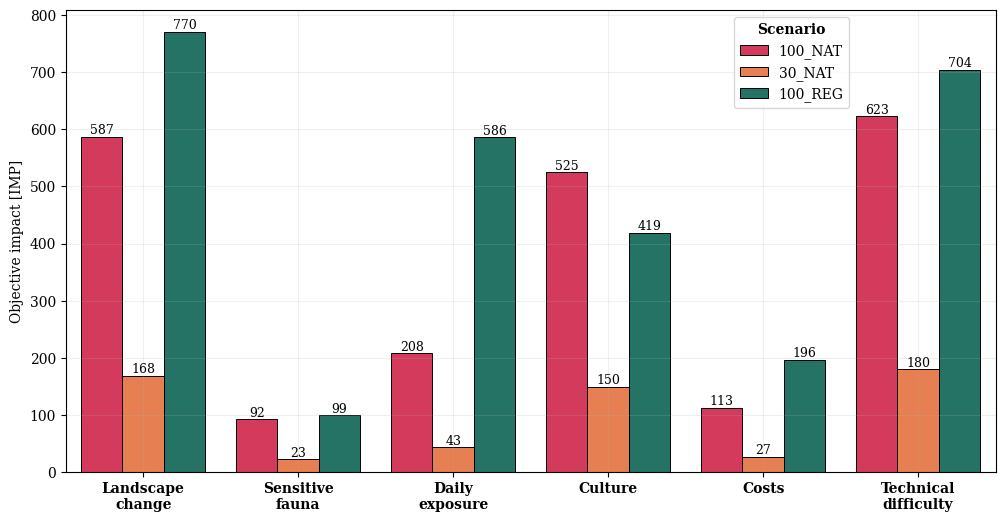

In [ ]:
### Prepare a dataframe to plot the TOTAL solution of the three scenarios over absolute objective impact values
scenario_vs_objective = best_solution_3scenarios.melt(
    id_vars="Scenario",
    value_vars=objective_names,
    var_name="Objective name",
    value_name="Objective value"
)

fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(data=scenario_vs_objective, x="Objective name", y="Objective value", hue="Scenario", palette=colors_3scenarios, linewidth=0.7, edgecolor='black', ax=ax)
ax.set_xticks(objective_names, labels=objective_names_plot_labels, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=9)
    
plt.legend(
    title="Scenario",
    bbox_to_anchor=(0.85, 1),
    loc="upper right",
    title_fontproperties={'weight': 'bold'},
)

plt.grid(axis="both", alpha=0.2)
# plt.title("Distribution of total impact per TWh values, separated per scenario")
plt.ylabel("Objective impact [IMP]")
plt.xlabel("")
plt.show()

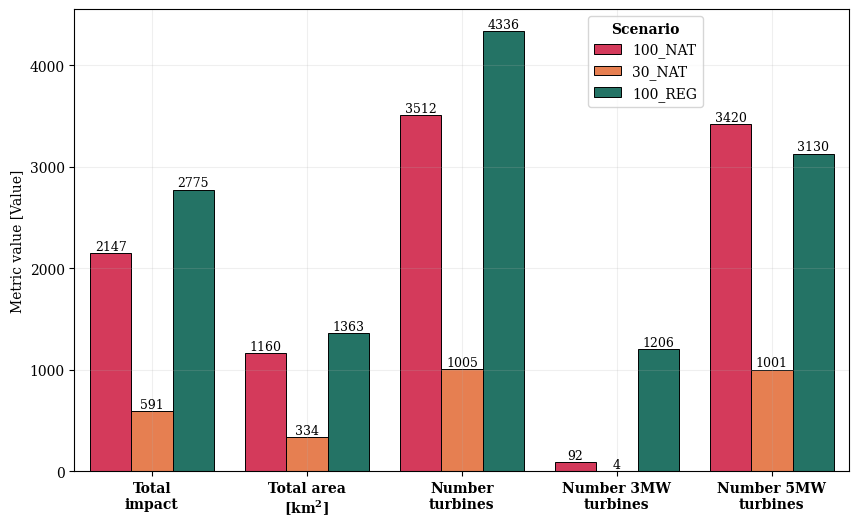

In [ ]:
### Prepare a dataframe to plot the TOTAL solution of the three scenarios over other absolute evaluation metric values (total impact, area and turbines used)
scenario_vs_metrics = best_solution_3scenarios.melt(
    id_vars="Scenario",
    value_vars=metrics_of_interest_absolute,
    var_name="Metric name",
    value_name="Metric value"
)

fig, ax = plt.subplots(figsize=(10,6))

sns.barplot(data=scenario_vs_metrics, x="Metric name", y="Metric value", hue="Scenario", palette=colors_3scenarios, linewidth=0.7, edgecolor='black', ax=ax)
ax.set_xticks(metrics_of_interest_absolute, labels=metrics_of_interest_plot_labels, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=9)

plt.legend(
    title="Scenario",
    bbox_to_anchor=(0.82, 1),
    loc="upper right",
    title_fontproperties={'weight': 'bold'},
)

plt.grid(axis="both", alpha=0.2)
# plt.title("Distribution of total impact per TWh values, separated per scenario")
plt.ylabel("Metric value [Value]")
plt.xlabel("")
plt.show()

# Additional plotting code that was not retained for the thesis

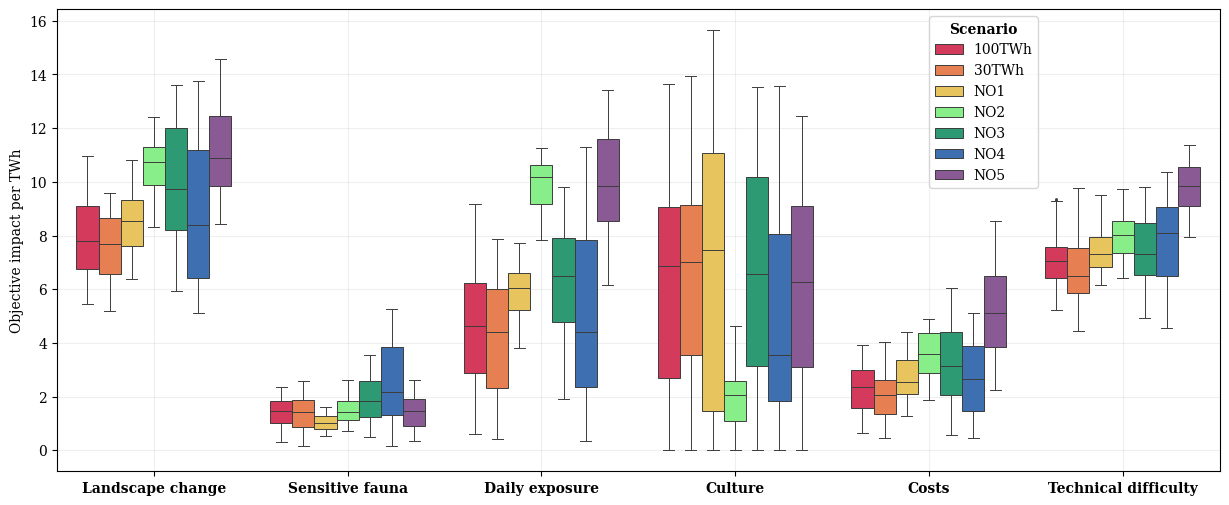

In [60]:
### Prepare a dataframe to plot the distribution of objective impacts per TWh across all scenarios and regions
scenario_vs_objective_per_TWh = solutions_big_gdf.melt(
    id_vars="Scenario",
    value_vars=objective_names_per_TWh,
    var_name="Objective name",
    value_name="Objective value"
)

# Plot
fig, ax = plt.subplots(figsize=(15,6))

sns.boxplot(data=scenario_vs_objective_per_TWh, x="Objective name", y="Objective value", hue="Scenario", palette=colors, linewidth=0.7, fliersize=1, ax=ax)
ax.set_xticks(objective_names_per_TWh, labels=objective_names, fontweight='bold')

plt.legend(
    title="Scenario",
    bbox_to_anchor=(0.85, 1),
    loc="upper right",
    title_fontproperties={'weight': 'bold'},
)

plt.grid(axis="both", alpha=0.2)
# plt.title("Distribution of total impact per TWh values, separated per scenario")
plt.ylabel("Objective impact per TWh")
plt.xlabel("")
plt.show()

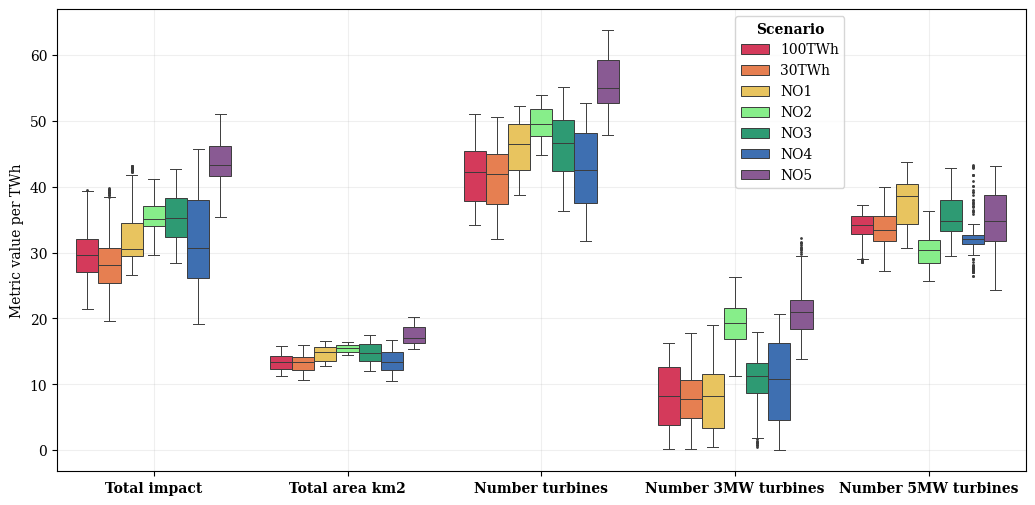

In [61]:
### Prepare a dataframe to plot the distribution of other evaluation metrics per TWh (total impact, area and turbines used) across all scenarios and regions
scenario_vs_metrics_per_TWh = solutions_big_gdf.melt(
    id_vars="Scenario",
    value_vars=metrics_of_interest_per_TWh,
    var_name="Metric name",
    value_name="Metric value"
)

# Plot
fig, ax = plt.subplots(figsize=(12.5,6))

sns.boxplot(data=scenario_vs_metrics_per_TWh, x="Metric name", y="Metric value", hue="Scenario", palette=colors, linewidth=0.7, fliersize=1, ax=ax)
ax.set_xticks(metrics_of_interest_per_TWh, labels=metrics_of_interest_absolute, fontweight='bold')

plt.legend(
    title="Scenario",
    bbox_to_anchor=(0.82, 1),
    loc="upper right",
    title_fontproperties={'weight': 'bold'},
)

plt.grid(axis="both", alpha=0.2)
# plt.title("Distribution of total impact per TWh values, separated per scenario")
plt.ylabel("Metric value per TWh")
plt.xlabel("")
plt.show()

In [62]:
### Scatter plots of the Pareto fronts across all scenarios and regions
def scatter_matrix(F, F_mcda, labels):
    n = F[0].shape[1]
    n_mcda = F_mcda[0].shape[0]
    fig, axes = plt.subplots(n-1, n-1, figsize=(2*n, 2*n))

    for s in range(len(scenarios)):

        for i in range(1, n):
            for j in range(n-1):
                ax = axes[i-1, j]


                if i == j:
                    ax.set_axis_off()

                elif i > j:
                    # Off-diagonal: scatter
                    if i == 1 and j == 0:
                        ax.scatter(F[s][:, j], F[s][:, i], color=colors[s], s=10, alpha=0.4, label="Scenario "+scenarios[s])
                    else:
                        ax.scatter(F[s][:, j], F[s][:, i], color=colors[s], s=10, alpha=0.4)
                else:
                    ax.set_axis_off()

                # Label only leftmost column and bottom row
                if j == 0:
                    ax.set_ylabel(labels[i])
                else:
                    ax.set_yticklabels([])

                if i == n - 1:
                    ax.set_xlabel(labels[j])
                else:
                    ax.set_xticklabels([])


    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    fig.suptitle("MOO solutions scattered according to objective values and with distinct colors per scenario")
    fig.legend(loc="center right")
    plt.show()

### Scatter plots of the MCDA solutions across all scenarios and regions
def scatter_matrix_MCDA(F, F_mcda, labels):
    n = F[0].shape[1]
    n_mcda = F_mcda[0].shape[0]
    fig, axes = plt.subplots(n-1, n-1, figsize=(2*n, 2*n))

    for s in range(len(scenarios)):

        for i in range(1, n):
            for j in range(n-1):
                ax = axes[i-1, j]

                if i == j:
                    ax.set_axis_off()

                elif i > j:
                    if i == 1 and j == 0:
                        for idx in range(n_mcda):
                            if idx == 0 :
                                ax.scatter(F_mcda[s][idx, j], F_mcda[s][idx, i], color=colors[s], marker="*", s=100, label= "Scenario " + scenarios[s])
                            else:
                                ax.scatter(F_mcda[s][idx, j], F_mcda[s][idx, i], color=colors[s], marker="*", s=100)
                    else:
                        for idx in range(n_mcda):
                            ax.scatter(F_mcda[s][idx, j], F_mcda[s][idx, i], color=colors[s], marker="*", s=100)                              

                else:
                    ax.set_axis_off()

                # Label only leftmost column and bottom row
                if j == 0:
                    ax.set_ylabel(labels[i])
                else:
                    ax.set_yticklabels([])

                if i == n - 1:
                    ax.set_xlabel(labels[j])
                else:
                    ax.set_xticklabels([])


    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    fig.suptitle("MCDA solutions scattered as stars with distinct colors per scenario")
    fig.legend(loc="center right")
    plt.show()

### Parallel coordinate plots of the MCDA solutions across all scenarios and regions
def plot_ParallelPlot(F, F_mcda):
    plot = PCP(title=("Objective values of MCDA", {'pad': 30}),
               legend=(True, {'loc': "upper left"}),
               labels=objective_names,
               tight_layout=True)
    plot.set_axis_style(color="grey", alpha=1)
    plot.normalize_each_axis = False

    for s in range(len(scenarios)):
        plot.add(F_mcda[s][0], color=colors[s], label= "Scenario "+scenarios[s])
        plot.add(F_mcda[s], color=colors[s])
        
    plot.show()
    plt.show()


In [63]:
# scatter_matrix(F_per_TWhs, F_mcda_per_TWh_7_objectivess, objective_names)
# scatter_matrix_MCDA(F_per_TWhs, F_mcda_per_TWh_7_objectivess, objective_names)
# plot_ParallelPlot(Fs, F_mcdas)

In [64]:
# ### Objective value per total impact, spread out over three subplots for all scenarios and regions

# fig, axes = plt.subplots(3, 1, figsize=(8, 14), sharex=True)

# for s in range(len(scenarios)):
#     x = solution_df_sorteds[s]["Total impact per TWh"]
#     #x = F_per_TWh.sum(axis=1)

#     x_mcda = F_mcda_per_TWh_7_objectivess[s].sum(axis=1)

#     handles = []
#     labels = []

#     pairs = [(0, 1), (2, 3), (4, 5)]

#     for ax, (i, j) in zip(axes, pairs):
#         for idx in (i, j):
#             y = solution_df_sorteds[s][objective_names_per_TWh[idx]]
#             #y = F_per_TWh[:,idx]
#             if idx == 0 :
#                 sc = ax.scatter(
#                     x,
#                     y,
#                     s=10,
#                     alpha=0.5,
#                     color=colors[s],
#                     label=scenarios[s],
#                 )
#             else:
#                 sc = ax.scatter(
#                     x,
#                     y,
#                     s=10,
#                     alpha=0.5,
#                     color=colors[s],
#                 )
#             # handles.append(sc)
#             # labels.append(objective_names[idx] + " MOO" + scenarios[s])
            
#             # for idx_2 in range(len(x_mcda)):
#             #     mcda_tip = ax.scatter(
#             #         x_mcda[idx_2],
#             #         F_mcda_per_TWh_7_objectivess[s][idx_2,idx],
#             #         s=300,
#             #         color=colors[s],
#             #         marker="*",
#             #     )
#             #     if idx == idx_2 or (idx == 5 and idx_2 == 6):
#             #         handles.append(mcda_tip)
#             #         labels.append(objective_names_7[idx_2] + " MCDA" + scenarios[s])

#         ax.set_ylim(0,14)
#         ax.grid(True)
#         ax.set_ylabel(overarching_objective_names[i//2])


# axes[-1].set_xlabel("Total impact per TWh")
# fig.suptitle("Objective value per total impact with distinct colors per scenario")
# fig.legend(loc="lower right")

# plt.tight_layout(rect=(0,0,0.85,0.99))
# plt.show()

In [65]:
# ### Number of turbines necessary for each solution with distinct colors per scenario and region
# plt.figure(figsize=(10, 8))

# for s in range(len(scenarios)):
#     plt.scatter(solution_df_sorteds[s]["Total impact per TWh"], solution_df_sorteds[s]["Number turbines"], s=10, color=colors[s], label="Total turbines for scenario " + scenarios[s])
#     #plt.scatter(solution_df_sorteds[s]["Total_impact_per_TWh"], solution_df_sorteds[s]["Number_3MW_turbines"], label="3 MW turbines for scenario " + scenarios[s])
#     #plt.scatter(solution_df_sorteds[s]["Total_impact_per_TWh"], solution_df_sorteds[s]["Number_5MW_turbines"], label="5 MW turbines for scenario " + scenarios[s])


# plt.title("Number of turbines necessary for each solution with distinct colors per scenario and region")
# plt.xlabel("Total impact per TWh [-]")
# plt.ylabel("Number of turbines [-]")
# plt.ylim(0,5500)
# plt.grid(True)
# plt.legend()

# plt.show()

In [66]:
# ### Number of 3 MW and 5 MW turbines necessary for each solution with distinct colors per scenario and region
# plt.figure(figsize=(10, 8))

# for s in range(1, len(scenarios)):
#     #plt.scatter(solution_df_sorteds[s]["Total_impact_per_TWh"], solution_df_sorteds[s]["Number_turbines"], label="Total turbines for scenario " + scenarios[s])
#     plt.scatter(solution_df_sorteds[s]["Total impact per TWh"], solution_df_sorteds[s]["Number 3MW turbines"], s=10, color=colors[s], label="3 MW turbines for scenario " + scenarios[s])
#     plt.scatter(solution_df_sorteds[s]["Total impact per TWh"], solution_df_sorteds[s]["Number 5MW turbines"], color=colors[s], marker='*', label="5 MW turbines for scenario " + scenarios[s])


# plt.title("Number of 3 MW and 5 MW turbines necessary for each solution with distinct colors per scenario and region")
# plt.xlabel("Total impact per TWh [-]")
# plt.ylabel("Number of turbines [-]")
# #plt.ylim(0,1)
# plt.grid(True)
# plt.legend()

# plt.show()

In [67]:
# ### Total area usage of the solutions and number of cells kept with distinct colors per scenario and region
# plt.figure(figsize=(10, 8))

# for s in range(1,len(scenarios)):
#     plt.scatter(solution_df_sorteds[s]["Total impact per TWh"], solution_df_sorteds[s]["Total area km2"], s=10, alpha=0.5, color=colors[s], label="Total area")
#     plt.scatter(solution_df_sorteds[s]["Total impact per TWh"], solution_df_sorteds[s]["Cells_kept"], s=50, alpha=0.3, color=colors[s], marker='*', label="Number of cells")


# plt.title("Total area usage of the solutions and number of cells kept with distinct colors per scenario and region")
# plt.xlabel("Total impact per TWh")
# plt.ylabel(r"Total area [$\mathregular{km^2}$]")
# plt.ylim(0,600)
# plt.grid(True)
# plt.legend()

# plt.show()

In [68]:
# ### Violin plots of the distribution of total impact (absolute and per TWh) across all scenarios and regions. Can be modified to study other distributions of interest
# plt.figure(figsize=(10,8))
# sns.violinplot(data=solutions_big_gdf, x="Scenario", y="Total impact", hue="Scenario", split=False, inner="quart")
# plt.title("Distribution of total impact values, separated per scenario")
# plt.ylabel("Total impact [-]")
# plt.xlabel("")
# plt.show()

# plt.figure(figsize=(10,8))
# sns.violinplot(data=solutions_big_gdf, x="Scenario", y="Total impact per TWh", hue="Scenario", split=False, inner="quart")
# plt.title("Distribution of total impact per TWh values, separated per scenario")
# plt.ylabel("Total impact per TWh [-]")
# plt.xlabel("")
# plt.show()

In [69]:
# ### Plots 4 plots: results of TOTAL across all scenarios and regions, over objective values and metric values (absolute and per TWh)

# df_long1 = best_solution_per_7scenario_gdf.melt(
#     id_vars="Scenario",
#     value_vars=objective_names,
#     var_name="Variable",
#     value_name="Value"
# )

# df_long1_per_TWh = best_solution_per_7scenario_gdf.melt(
#     id_vars="Scenario",
#     value_vars=objective_names_per_TWh,
#     var_name="Variable",
#     value_name="Value"
# )

# df_long2 = best_solution_per_7scenario_gdf.melt(
#     id_vars="Scenario",
#     value_vars=metrics_of_interest_absolute,
#     var_name="Variable",
#     value_name="Value"
# )

# df_long2_per_TWh = best_solution_per_7scenario_gdf.melt(
#     id_vars="Scenario",
#     value_vars=metrics_of_interest_per_TWh,#+["Fraction_area_usage"],
#     var_name="Variable",
#     value_name="Value"
# )

# plt.figure(figsize=(14, 6))
# plt.tight_layout()

# ax = sns.barplot(
#     data=df_long1,
#     x="Variable",
#     y="Value",
#     hue="Scenario"
# )
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.0f", fontsize=9)

# plt.xticks(rotation=45, ha="right")
# plt.ylabel("Value")
# plt.xlabel("")
# plt.title("Comparison of best solutions for each scenario across variables")
# plt.show()


# plt.figure(figsize=(14, 6))
# plt.tight_layout()

# ax = sns.barplot(
#     data=df_long1_per_TWh,
#     x="Variable",
#     y="Value",
#     hue="Scenario"
# )
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.1f", fontsize=9)

# plt.xticks(rotation=45, ha="right")
# plt.ylabel("Value")
# plt.xlabel("")
# #plt.legend(loc="upper right")
# plt.title("Comparison of best solutions for each scenario across variables")

# plt.show()

# plt.figure(figsize=(14, 6))
# plt.tight_layout()

# ax = sns.barplot(
#     data=df_long2,
#     x="Variable",
#     y="Value",
#     hue="Scenario"
# )
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.0f", fontsize=9)

# plt.xticks(rotation=45, ha="right")
# plt.ylabel("Value")
# plt.xlabel("")
# plt.title("Comparison of best solutions for each scenario across variables")
# plt.show()


# plt.figure(figsize=(14, 6))
# plt.tight_layout()

# ax = sns.barplot(
#     data=df_long2_per_TWh,
#     x="Variable",
#     y="Value",
#     hue="Scenario"
# )
# for container in ax.containers:
#     ax.bar_label(container, fmt="%.0f", fontsize=9)

# plt.xticks(rotation=45, ha="right")
# plt.ylabel("Value")
# plt.xlabel("")
# plt.title("Comparison of best solutions for each scenario across variables")
# plt.show()

In [70]:
def calculate_X_robustness(X, my_input_data): 
    unit_counts = {}
    for i in range(len(my_input_data)):
        unit_counts[i] = 0

    # Iterate through the optimal solutions
    for solution in X:
        # Get indices of selected units (assuming binary solutions)
        selected_indices = np.where(solution == True)[0]
        # Increment counts for selected units
        for idx in selected_indices:
            unit_counts[idx] += 1

    # Print the counts
    #for unit_id, count in unit_counts.items():
    #    print(f"Planning Unit {unit_id}: {count} occurrences")
    count_series = pd.Series({k: v for k, v in unit_counts.items()}, name="Optimizer_selection_count")
    my_input_data_temp = my_input_data.copy().reset_index(drop=True)  # Drop the old index
    if "Optimizer_selection_count" in my_input_data_temp.columns:
        my_input_data_temp = my_input_data_temp.drop(columns="Optimizer_selection_count")
    my_input_data_temp = my_input_data_temp.join(count_series)
    my_input_data_temp["Optimizer_selection_frequency"] = my_input_data_temp["Optimizer_selection_count"] / len(X)

    # Copy to avoid SettingWithCopyWarning
    gdf = my_input_data_temp.copy()

    return gdf

In [71]:
# ### Study the robustness of cells across the different scenarios and regions

# X_robustnesss = []
# X_robustness_sorteds = []
# most_robusts = []

# for s in range(len(scenarios)):
#     X_robustnesss.append(calculate_X_robustness(Xs[s], my_input_datas[s]))
#     X_robustness_sorteds.append(X_robustnesss[s].sort_values("Optimizer_selection_count", ascending=False).copy())
#     X_robustness_sorteds[s]["Cumulative_prod"] = X_robustness_sorteds[s]["AEP_GWh"].cumsum()

#     # a convoluted way of selecting the first cell which has a cumulative production greater or equal to (ge()) the minimum production desired, in a dataframe sorted by decreasing robustness of cells
#     most_robusts.append(X_robustness_sorteds[s].loc[:X_robustness_sorteds[s]["Cumulative_prod"].ge(min_productions[s]).idxmax()])

# X_robust_cellss =[]
# for s in range(len(scenarios)):
#     X_robust_cellss.append(my_input_datas[s]["SSBid"].isin(most_robusts[s]["SSBid"].values).to_numpy())

# robustness_evolutions = []
# for s in range(len(scenarios)):
#     robustness_evolutions.append(np.zeros(number_solutions))
#     for i in range(number_solutions):
#         nb_selected_cells = X_robustnesss[s][X_robustnesss[s]["Optimizer_selection_count"] > i].shape[0]
#         robustness_evolutions[s][i] = nb_selected_cells

# plt.figure(figsize=(8, 12))

# for s in range(len(scenarios)):
#     plt.plot(np.arange(number_solutions)/number_solutions, robustness_evolutions[s]/Xs[s].shape[1], c=colors[s])
#     plt.hlines(most_robusts[s].shape[0]/Xs[s].shape[1], 0, 1, colors=colors[s], label="Minimum fraction of robust cells needed for " + scenarios[s] + " production")
    
# plt.title("Fraction of cells at specific selection frequencies")
# plt.xlabel("Selection frequency [-]")
# plt.ylabel("Cell fraction [-]")
# plt.ylim(0,0.2)
# plt.grid(True, which='both')
# plt.legend()

# plt.show()

In [72]:
# ### Plot the fraction of land area used per scenario and region
# plt.figure(figsize=(6,5))
# sns.barplot(data=best_solution_per_7scenario_gdf, x="Scenario", y="Fraction area usage", hue="Scenario", linewidth=0.7, edgecolor='black')
# plt.title("Fraction of land area used per scenario and region")
# plt.ylabel("Area fraction [-]")
# plt.xlabel("")
# # plt.ylim(0,1)
# plt.show()

In [ ]:
# ### In case for some reason one needs all of the best solutions possible
# best_totals = []
# best_envs = []    # environmental dimension
# best_socs = []    # social dimension
# best_costs = []    # techno-economic dimension
# best_Landscapes = []
# best_Sensitives = []
# best_Dailys = []
# best_Cultures = []
# best_Costss = []
# best_Technicals = []

# for s in range(len(scenarios)):
#     best_totals.append(np.argmin(solution_dfs[s]["Total impact per TWh"]))  # lowest total

#     best_envs.append(np.argmin(Fs[s][:,0] + Fs[s][:,1]))   # lowest environmental impact
#     best_socs.append(np.argmin(Fs[s][:,2] + Fs[s][:,3]))   # lowest social impact
#     best_costs.append(np.argmin(Fs[s][:,4] + Fs[s][:,5]))  # lowest techno-economic

#     # best_Landscapes.append(np.argmin(Fs[s][:,0]))
#     # best_Sensitives.append(np.argmin(Fs[s][:,1]))
#     # best_Dailys.append(np.argmin(Fs[s][:,2]))
#     # best_Cultures.append(np.argmin(Fs[s][:,3]))
#     # best_Costss.append(np.argmin(Fs[s][:,4]))
#     # best_Technicals.append(np.argmin(Fs[s][:,5]))

#     best_Landscapes.append(np.argmin(solution_dfs[s]["Landscape change per TWh"]))
#     best_Sensitives.append(np.argmin(solution_dfs[s]["Sensitive fauna per TWh"]))
#     best_Dailys.append(np.argmin(solution_dfs[s]["Daily exposure per TWh"]))
#     best_Cultures.append(np.argmin(solution_dfs[s]["Culture per TWh"]))
#     best_Costss.append(np.argmin(solution_dfs[s]["Costs per TWh"]))
#     best_Technicals.append(np.argmin(solution_dfs[s]["Technical difficulty per TWh"]))
